In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import os

# ==========================================
# 1. Pipeline Configuration
# ==========================================
# List your 8 sensor IDs exactly as they appear in the CSV filenames/SITE_ID
sensor_ids = ['463'] 

# (Optional) If traffic is one master file for all sensors, load it once here.
# If it's separate files per sensor, move this into the loop.
# df_traffic_master = pd.read_csv('all_traffic_data.csv')

# Dictionary to store our fitted models and cleaned data for later plotting
results_dict = {}

print("Starting MLR Pipeline...\n" + "="*40)

for s_id in sensor_ids:
    print(f"\nAnalyzing Sensor: {s_id}")
    
    # ==========================================
    # 2. Load Data
    # ==========================================
    # Load the specific tree file for this sensor
    tree_file = f'tree_output_{s_id}.csv'
    if not os.path.exists(tree_file):
        print(f"  -> File {tree_file} not found. Skipping.")
        continue
    df_tree = pd.read_csv(tree_file)
    
    # Load or filter the traffic data
    df_traffic = pd.read_csv(f'../Traffic Data/pollution_{s_id}.csv') 
    # OR if using a master traffic file:
    # df_traffic = df_traffic_master[df_traffic_master['SITE_ID'] == int(s_id)].copy()
    
    # ==========================================
    # 3. Temporal Alignment (The Timezone Fix)
    # ==========================================
    # Convert both to Pandas datetime objects
    df_tree['dt_merge'] = pd.to_datetime(df_tree['DATE_TIME_STR'])
    df_traffic['dt_merge'] = pd.to_datetime(df_traffic['DATE_TIME'])
    
    # Force both columns to be "timezone-naive" so they match perfectly
    # .dt.tz_localize(None) strips away the '+00:00' from the traffic data
    # Force both columns to be "timezone-naive" so they match perfectly
    if df_tree['dt_merge'].dt.tz is not None:
        df_tree['dt_merge'] = df_tree['dt_merge'].dt.tz_localize(None)
    if df_traffic['dt_merge'].dt.tz is not None:
        df_traffic['dt_merge'] = df_traffic['dt_merge'].dt.tz_localize(None)
        
    # Merge on the aligned datetime column
    df_merged = pd.merge(df_tree, df_traffic, on='dt_merge', how='inner')
    
    # ==========================================
    # 4. Cleaning & NaN Removal
    # ==========================================
    initial_len = len(df_merged)
    # We only need these three columns to run the MLR
    cols_to_check = ['NOX', 'G_h_effective', 'traffic_nox_index']
    
    df_clean = df_merged.dropna(subset=cols_to_check).copy()
    print(f"  -> Data matched/cleaned: {len(df_clean)} valid hours remaining.")
    
    if len(df_clean) == 0:
        print("  -> Error: No overlapping data. Check your timestamps!")
        continue
        
    # ==========================================
    # 5. Standardization (Z-Scores)
    # ==========================================
    # Z = (Value - Mean) / Standard Deviation
    df_clean['Z_trees'] = (df_clean['G_h_effective'] - df_clean['G_h_effective'].mean()) / df_clean['G_h_effective'].std()
    df_clean['Z_traffic'] = (df_clean['traffic_nox_index'] - df_clean['traffic_nox_index'].mean()) / df_clean['traffic_nox_index'].std()
    
    # ==========================================
    # 6. Multiple Linear Regression (MLR)
    # ==========================================
    # Define Independent Variables (X) and Target Variable (y)
    X = df_clean[['Z_traffic', 'Z_trees']]
    y = df_clean['NOX']
    
    # Add the intercept (beta_0) - Required for Statsmodels
    X = sm.add_constant(X)
    
    # Fit the model
    model = sm.OLS(y, X).fit()
    
    # Extract Metrics
    b0 = model.params['const']
    b_traffic = model.params['Z_traffic']
    b_trees = model.params['Z_trees']
    p_trees = model.pvalues['Z_trees']
    r_sq = model.rsquared
    
    # Print a clean, academic summary for this sensor
    print(f"  -> R-squared: {r_sq:.4f}")
    print(f"  -> Background NOx (Intercept): {b0:.2f} µg/m³")
    print(f"  -> Traffic Coefficient:  +{b_traffic:.4f} (p={model.pvalues['Z_traffic']:.3e})")
    print(f"  -> Tree Coefficient:     {b_trees:.4f} (p={p_trees:.3e})")
    
    if b_trees < 0 and p_trees < 0.05:
        print("  >>> SUCCESS: Significant tree sink effect detected! <<<")
    elif b_trees < 0:
        print("  >>> Note: Tree effect is negative, but not statistically significant.")
    else:
        print("  >>> Warning: Tree coefficient is positive.")

    # Save residuals for later analysis/plotting
    df_clean['residuals'] = model.resid
    
    # Store everything in the dictionary
    results_dict[s_id] = {
        'model': model,
        'data': df_clean,
        'summary': model.summary()
    }

# ==========================================
# Optional: Print Full Academic Summary for a specific sensor
# print(results_dict['203']['summary'])

Starting MLR Pipeline...

Analyzing Sensor: 463
  -> Data matched/cleaned: 8564 valid hours remaining.
  -> R-squared: 0.0092
  -> Background NOx (Intercept): 46.55 µg/m³
  -> Traffic Coefficient:  +4.1376 (p=7.797e-18)
  -> Tree Coefficient:     -1.7145 (p=3.555e-04)
  >>> SUCCESS: Significant tree sink effect detected! <<<



Generating Master Residual Plot...


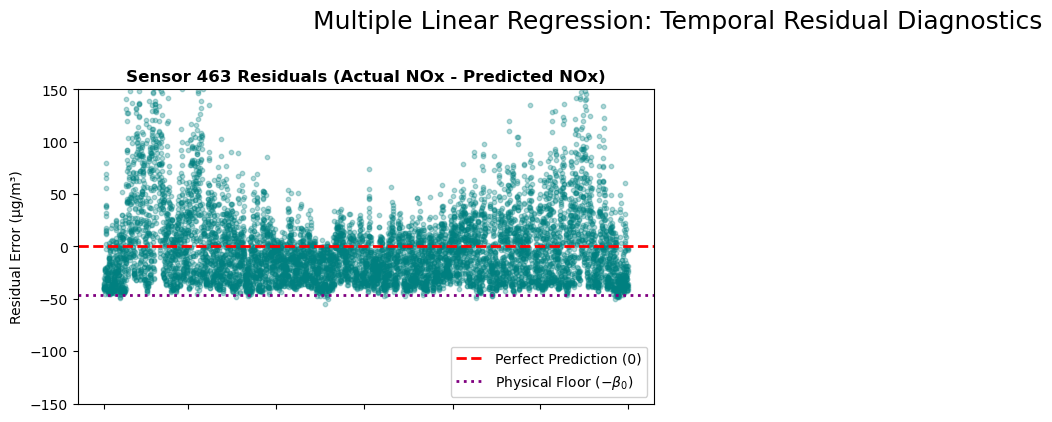

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# 7. Residual Diagnostics Visualization
# ==========================================

def plot_master_residuals(results_dictionary):
    """
    Creates a 4x2 grid plotting the residuals over time for all 8 sensors.
    """
    # Create a large figure with 4 rows and 2 columns
    fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20), sharex=True)
    fig.subplots_adjust(hspace=0.3, wspace=0.15)
    
    # Flatten the 4x2 axes array into a 1D list so we can loop through it easily
    axes = axes.flatten()
    
    print("\nGenerating Master Residual Plot...")
    
    for i, (s_id, result) in enumerate(results_dictionary.items()):
        ax = axes[i]
        df = result['data']
        
        # Extract the background NOx (Intercept)
        b0 = result['model'].params['const']
        
        # We plot Residuals vs Time
        # Plotting a scatter with low alpha so dense clusters don't become a solid block
        ax.scatter(df['dt_merge'], df['residuals'], alpha=0.3, s=10, color='teal')
        
        # Draw the critical Zero Line (with label for legend)
        ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction (0)')
        
        # Draw the Physical Floor Line (-b0) (with label for legend)
        ax.axhline(-b0, color='purple', linestyle=':', linewidth=2, label=r'Physical Floor ($-\beta_0$)')
        
        # Formatting
        ax.set_title(f'Sensor {s_id} Residuals (Actual NOx - Predicted NOx)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Residual Error (µg/m³)', fontsize=10)
        
        # Format the x-axis to look nice with dates
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.tick_params(axis='x', rotation=30)
        
        # # Add a text box with the R-squared and Tree P-value for quick reference
        # r2 = result['model'].rsquared
        # p_tree = result['model'].pvalues['Z_trees']
        # b_tree = result['model'].params['Z_trees']
        
        # stats_text = f"R² = {r2:.3f}\nTree Coeff: {b_tree:.2f}\nTree p = {p_tree:.1e}"
        # ax.text(0.02, 0.85, stats_text, transform=ax.transAxes, 
        #         fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
        
        # Add the legend to the plot (placed in the lower right to avoid the data/text box)
        ax.legend(loc='lower right', fontsize=10, facecolor='white', framealpha=0.9)
        
        # Optional: Set Y-limits to be uniform across all plots for fair comparison
        ax.set_ylim(-150, 150) 
        
    # If you have less than 8 sensors in a test run, hide the empty subplots
    for j in range(i + 1, 8):
        fig.delaxes(axes[j])
        
    plt.suptitle("Multiple Linear Regression: Temporal Residual Diagnostics", fontsize=18, y=0.92)
    plt.show()

# --- Run the Plotter ---
# Only run this if your results_dict actually populated successfully!
if len(results_dict) > 0:
    plot_master_residuals(results_dict)
else:
    print("No data in results_dict to plot.")